In [260]:
import pandas as pd
from rdkit import Chem
import sklearn
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import f1_score
from rdkit.Chem import Draw
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from rdkit.Chem import rdMolDescriptors
from collections import defaultdict


In [261]:
def is_rotatable_bond(bond):
    """Return True if bond is a rotatable bond (RDKit style, single non‑ring)."""
    if bond.GetIsAromatic():
        return False
    if bond.IsInRing():
        return False
    begin_atom = bond.GetBeginAtom()
    end_atom = bond.GetEndAtom()
    # Exclude amide‑type bonds (C=O–N) and similar
    if (begin_atom.GetAtomicNum() == 7 and end_atom.GetAtomicNum() == 6) or \
       (begin_atom.GetAtomicNum() == 6 and end_atom.GetAtomicNum() == 7):
        # Check if part of C(=O)‑N
        if any(
            nB.GetBondType() == Chem.BondType.DOUBLE
            for nB in begin_atom.GetBonds()
        ):
            return False
    return True

def get_rotatable_bond_graph(mol):
    rot_bonds = set()
    for bond in mol.GetBonds():
        if is_rotatable_bond(bond):
            a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            rot_bonds.add((min(a1, a2), max(a1, a2)))

    adj = defaultdict(set)
    for a, b in rot_bonds:
        adj[a].add(b)
        adj[b].add(a)
    return adj


In [262]:
# Remove everything with a double or a tripe bond and Benzene with a N+-CH3

In [263]:
# df = pd.read_csv("Herg_Tune_Lab_prediction.csv")
df = pd.read_csv("hERG_Dataset_REDO.csv")

In [264]:
df["mol"] = df["canonical_smiles"].apply(lambda x: Chem.MolFromSmiles(x) if pd.notna(x) else None)
df["drop_for_flex"] = df["mol"].apply(
    lambda m: has_long_rotatable_path(m, max_consecutive=5) if m is not None else True
)
df = df[~df["drop_for_flex"]].copy()

In [265]:
df

,Unnamed: 0,assay_chembl_id,assay_description,canonical_smiles,molecule_chembl_id,standard_type,standard_units,standard_value,target_pref_name,type,units,value,"hERG Binding (Astemizole, IC50, uM)_value",Chembl_Astemizole_binding,experimental_class,predicted_class,pIC50_Experimental,mol,drop_for_flex
2,5943.0,CHEMBL2395084,Displacement of [3H]Astemizole from human reco...,COc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2...,CHEMBL296419,Ki,nM,2.1,HERG,Ki,nM,2.100,< 10uM,1.0,1.0,1.0,8.678,<rdkit.Chem.rdchem.Mol object at 0x7fa30a731000>,False
6,4287.0,CHEMBL1837909,Displacement of [3H]-astemizole from human ERG...,COc1ccc([C@H]2CC[C@@H](N3CC(NC(=O)CNc4noc5ccc(...,CHEMBL1834852,IC50,nM,8.7,HERG,IC50,nM,8.700,< 10uM,1.0,1.0,1.0,8.060,<rdkit.Chem.rdchem.Mol object at 0x7fa30a730e40>,False
8,5720.0,CHEMBL2330781,Displacement of [3H]astemizole from human ERG ...,Clc1ccc(OCCCc2cccc(CCCOc3ccc(Cl)cc3)n2)cc1,CHEMBL2324257,IC50,nM,9.9,HERG,IC50,nM,9.900,> 30uM,1.0,1.0,0.0,8.004,<rdkit.Chem.rdchem.Mol object at 0x7fa30a730d60>,False
9,4285.0,CHEMBL1837909,Displacement of [3H]-astemizole from human ERG...,O=C(CNc1noc2ccc(C(F)(F)F)cc12)NC1CN([C@H]2CC[C...,CHEMBL1834854,IC50,nM,11.0,HERG,IC50,nM,11.000,< 10uM,1.0,1.0,1.0,7.959,<rdkit.Chem.rdchem.Mol object at 0x7fa30a730cf0>,False
10,283.0,CHEMBL839576,Inhibition of [3H]astemizole binding to Potass...,O=C1NC(=O)C(c2nn(CCCN3CCCC3)c3ccccc23)=C1c1cn(...,CHEMBL367107,Ki,nM,11.0,HERG,Ki,uM,0.011,< 10uM,1.0,1.0,1.0,7.959,<rdkit.Chem.rdchem.Mol object at 0x7fa30a730c80>,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,9997.0,CHEMBL4706939,Displacement of [3H]astemizole from human ERG ...,Cc1cnc(-c2cnc(Nc3cnc(C#N)cn3)cc2NC[C@H]2CNCCO2)s1,CHEMBL4742233,IC50,nM,56000.0,HERG,IC50,uM,56.000,> 30uM,1.0,0.0,0.0,4.252,<rdkit.Chem.rdchem.Mol object at 0x7fa3105a6340>,False
289,5406.0,CHEMBL2166760,Displacement of [3H]-astemizole from human ERG...,N#Cc1ccc2ccc(=O)n(CCN3CC[C@H](NCc4cc5c(cn4)OCC...,CHEMBL2165068,IC50,nM,57000.0,HERG,IC50,uM,57.000,> 30uM,1.0,0.0,0.0,4.244,<rdkit.Chem.rdchem.Mol object at 0x7fa3105a62d0>,False
290,4718.0,CHEMBL1960000,Displacement of [3H]-astemizole from human ERG...,CS(=O)(=O)N1CCN(Cc2cc3nc(-c4cccc5[nH]ncc45)nc(...,CHEMBL521851,IC50,nM,64000.0,HERG,IC50,uM,64.000,> 30uM,1.0,0.0,0.0,4.194,<rdkit.Chem.rdchem.Mol object at 0x7fa3105a6260>,False
291,4454.0,CHEMBL1909190,DRUGMATRIX: Potassium Channel HERG radioligand...,Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1,CHEMBL715,IC50,nM,100000.0,HERG,IC50,uM,100.000,> 30uM,1.0,0.0,0.0,4.000,<rdkit.Chem.rdchem.Mol object at 0x7fa3105a61f0>,False


In [266]:
pattern_smarts_arom_pos_N = Chem.MolFromSmarts("c1cc[n+](C)cc1")
pattern_double_bonds = Chem.MolFromSmarts("C=C")
pattern_triple_bonds = Chem.MolFromSmarts("C#C")

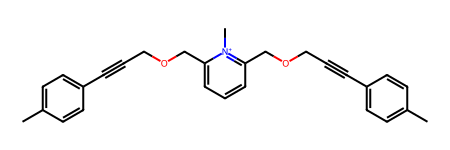

In [267]:
Chem.MolFromSmiles("Cc1ccc(C#CCOCc2cccc(COCC#Cc3ccc(C)cc3)[n+]2C)cc1")

In [268]:
df['Pos_Charge_Arom_N'] = df['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(pattern_smarts_arom_pos_N))

In [269]:
df['double_bonds'] = df['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(pattern_double_bonds))

In [270]:
df['triple_bonds'] = df['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(pattern_triple_bonds))

In [271]:
df = df[(df['Pos_Charge_Arom_N']==False) & (df['double_bonds']==False) & (df['triple_bonds']==False)]

In [272]:
df['Chembl_Astemizole_binding'] = df['assay_description'].str.contains("astemizole", case=False, na=False)

/tmp/ipykernel_2282/1813123366.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Chembl_Astemizole_binding'] = df['assay_description'].str.contains("astemizole", case=False, na=False)


In [273]:
df_astemizole = df[df['Chembl_Astemizole_binding'] == True]

In [274]:
df_astemizole = df_astemizole.sort_values(by=['standard_value'])

In [275]:
df_astemizole = df_astemizole.drop_duplicates(subset=['canonical_smiles'])

In [276]:
set(df_astemizole['hERG Binding (Astemizole, IC50, uM)_value'])

{'< 10uM', '> 30uM'}

In [277]:
# convert standard nM to UM 

df_astemizole["experimental_class"] = np.where(df_astemizole["standard_value"] < 10000, 1,
                       np.where(df_astemizole["standard_value"] > 30000, 0, np.nan))

In [278]:
df_astemizole[df_astemizole['experimental_class']==0].shape[0]/df_astemizole.shape[0]

0.18404907975460122

In [279]:
df_astemizole.columns

Index(['Unnamed: 0', 'assay_chembl_id', 'assay_description',
       'canonical_smiles', 'molecule_chembl_id', 'standard_type',
       'standard_units', 'standard_value', 'target_pref_name', 'type', 'units',
       'value', 'hERG Binding (Astemizole, IC50, uM)_value',
       'Chembl_Astemizole_binding', 'experimental_class', 'predicted_class',
       'pIC50_Experimental', 'mol', 'drop_for_flex', 'Pos_Charge_Arom_N',
       'double_bonds', 'triple_bonds'],
      dtype='object')

In [280]:
df_astemizole["predicted_class"] = np.where(df_astemizole["hERG Binding (Astemizole, IC50, uM)_value"] == '< 10uM', 1,
                       np.where(df_astemizole["hERG Binding (Astemizole, IC50, uM)_value"] == '> 30uM', 0, np.nan))

In [281]:
df_herg_astemizole_class = df_astemizole.dropna(subset=['experimental_class'])

In [282]:
df_astemizole[df_astemizole['experimental_class']==1].shape[0]/df_astemizole.shape[0]

0.8159509202453987

In [283]:
cm = confusion_matrix(df_herg_astemizole_class['experimental_class'], df_herg_astemizole_class['predicted_class'])

In [284]:
cm

array([[23,  7],
       [68, 65]])

In [285]:
precision_score(df_herg_astemizole_class['experimental_class'], df_herg_astemizole_class['predicted_class'])

0.9027777777777778

In [286]:
recall_score(df_herg_astemizole_class['experimental_class'], df_herg_astemizole_class['predicted_class'])

0.48872180451127817

In [287]:
accuracy_score(df_herg_astemizole_class['experimental_class'], df_herg_astemizole_class['predicted_class'])

0.5398773006134969

In [288]:
f1_score(df_herg_astemizole_class['experimental_class'], df_herg_astemizole_class['predicted_class'])

0.6341463414634146

In [289]:
fpr_lr, tpr_lr, _ = roc_curve(df_herg_astemizole_class['experimental_class'], df_herg_astemizole_class['predicted_class'])
roc_auc_lr = auc(fpr_lr, tpr_lr)
print(roc_auc_lr)

0.6276942355889723


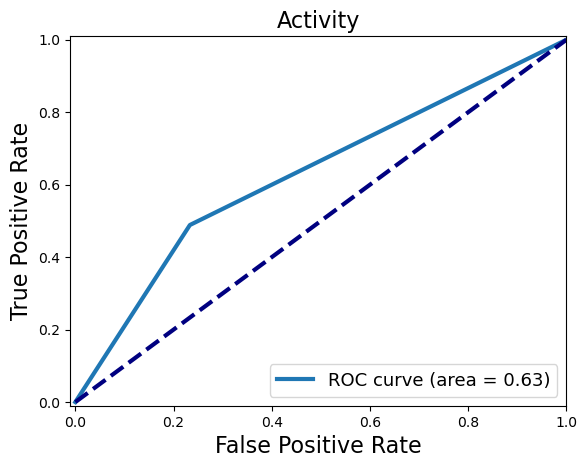

In [290]:
plt.figure()
plt.xlim([-0.01, 1.00])
plt.ylim([-0.01, 1.01])
plt.plot(fpr_lr, tpr_lr, lw=3, label='ROC curve (area = {:0.2f})'.format(roc_auc_lr))
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('Activity', fontsize=16)
plt.legend(loc='lower right', fontsize=13)
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.axes().set_aspect('equal')
# plt.show()

In [291]:
#Precision = 0.935: When the model predicts “hERG active”, it is almost always correct, with very few false positives.
#Recall = 0.35: The model only finds about 35% of the truly hERG‑active compounds, so it is missing the majority of actives (many false negatives).
#F1 = 0.51: This reflects the imbalance between very high precision and low recall; the harmonic mean penalizes the low recall and ends up around 0.5.

In [292]:
# As a rule‑in tool, the model is useful: predicted hERG actives are likely real actives, which is good if you want high confidence that flagged 
# compounds are genuinely risky.
# As a screening or safety net tool, it is risky: with recall at 0.35, many genuinely hERG‑active compounds will be classified as inactive, which is 
# problematic for liability filtering.

In [293]:
df_herg_astemizole_class = df_herg_astemizole_class.sort_values(by=['standard_value'])

In [294]:
mols_tp = [Chem.MolFromSmiles(x) for x in df_herg_astemizole_class[(df_herg_astemizole_class['experimental_class']==1) & (df_herg_astemizole_class['predicted_class']==1)]['canonical_smiles']]

In [295]:
id_tp = [x for x in df_herg_astemizole_class[(df_herg_astemizole_class['experimental_class']==1) & (df_herg_astemizole_class['predicted_class']==1)]['molecule_chembl_id']]

In [296]:
activity_tp = [x for x in df_herg_astemizole_class[(df_herg_astemizole_class['experimental_class']==1) & (df_herg_astemizole_class['predicted_class']==1)]['standard_value']]

In [297]:
predict_tp = [x for x in df_herg_astemizole_class[(df_herg_astemizole_class['experimental_class']==1) & (df_herg_astemizole_class['predicted_class']==1)]['hERG Binding (Astemizole, IC50, uM)_value']]

In [298]:
df_herg_astemizole_class.shape

(163, 22)

In [299]:
df_herg_astemizole_class['pIC50_Experimental'] = df_herg_astemizole_class['standard_value'].apply(lambda x: -np.log10(x*pow(10,-9)))

In [300]:
df_herg_astemizole_class.to_csv("/mnt/c/Users/sande/Documents/Recludix/Tune_Lab/Tune_Lab_Herg_Analysis.csv", index=False)

In [301]:
# id_act_tp  =list(zip(id_tp,activity_tp))
id_act_tp = [f"{chembl}_{value}nM;{val}" for chembl, value, val in list(zip(id_tp,activity_tp,predict_tp))]

In [302]:
len(id_act_tp)

65

In [303]:
img = Draw.MolsToGridImage(
    mols_tp,
    molsPerRow=4,
    subImgSize=(250, 250),
    legends=id_act_tp
)

/home/spal/miniconda3/envs/espsim/lib/python3.12/site-packages/rdkit/Chem/Draw/IPythonConsole.py:344: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


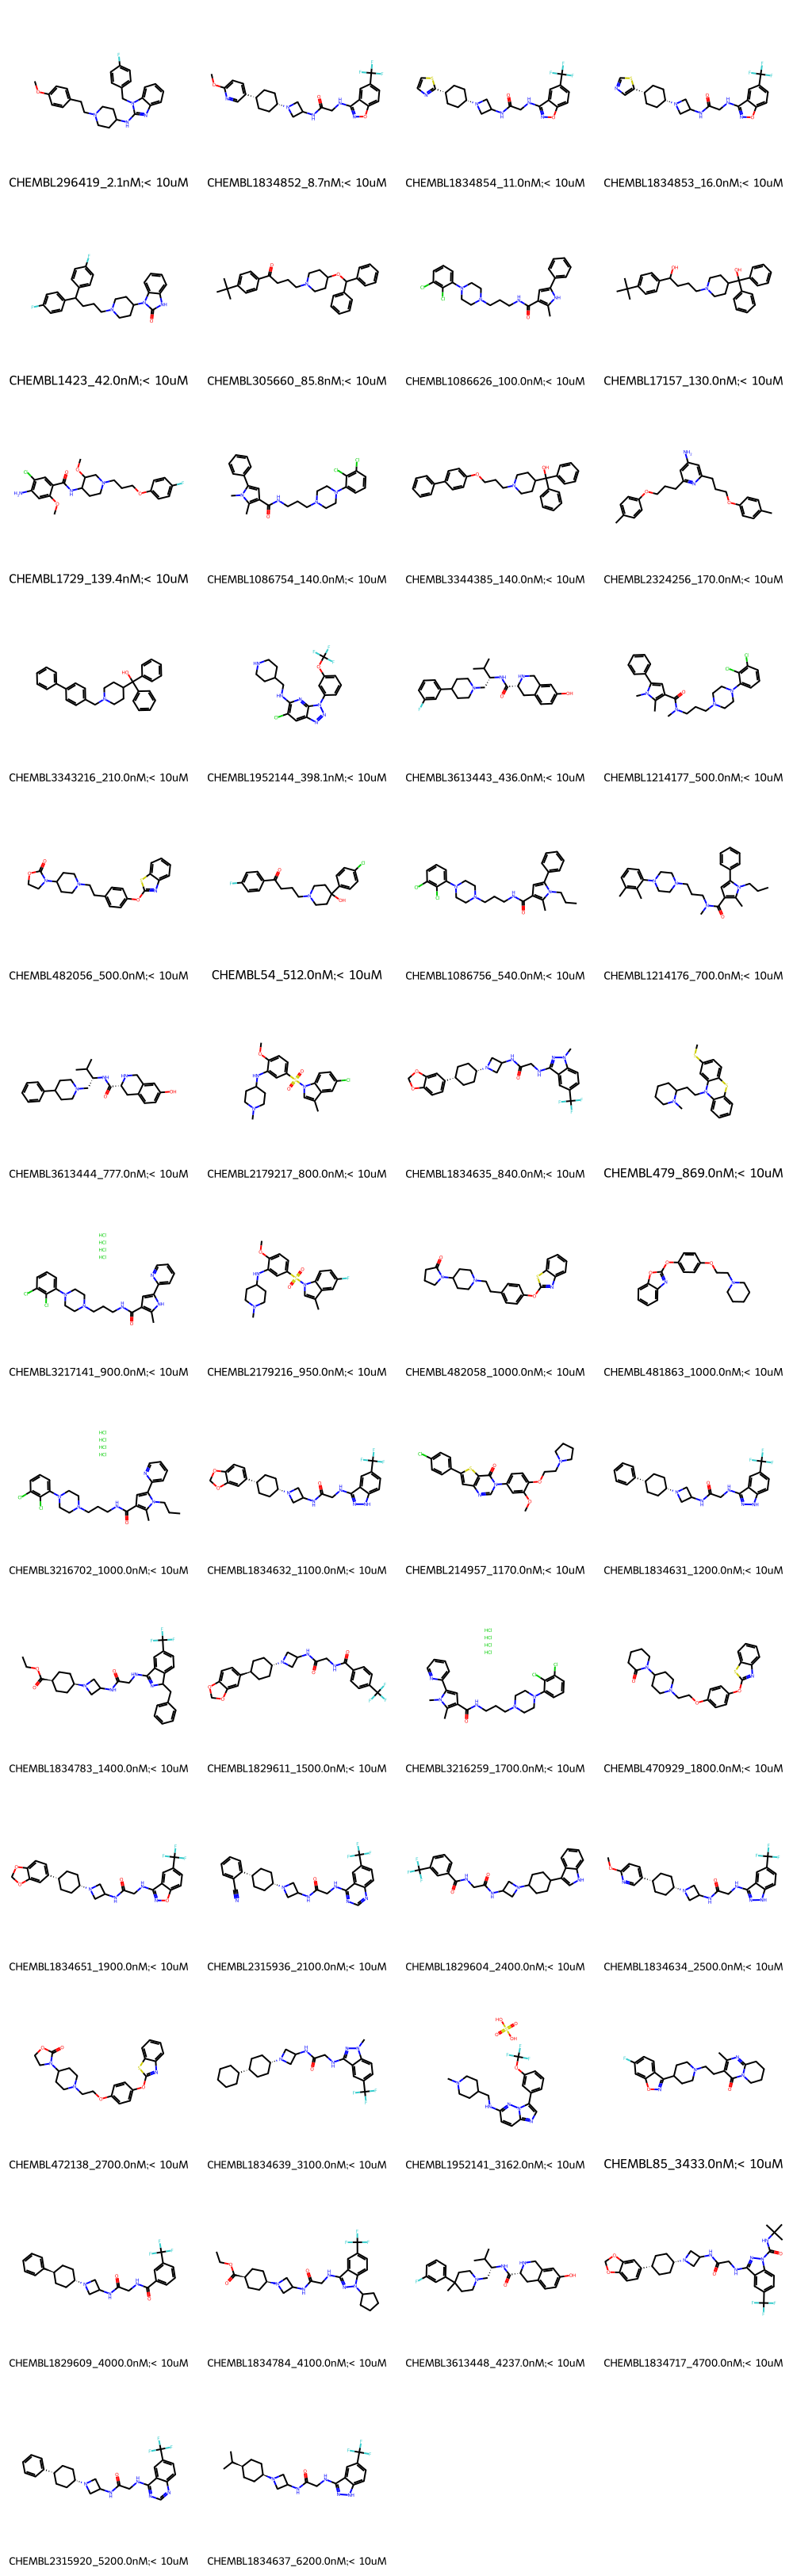

In [304]:
img

In [305]:
mols_fn = [Chem.MolFromSmiles(x) for x in df_herg_astemizole_class[(df_herg_astemizole_class['experimental_class']==1) & (df_herg_astemizole_class['predicted_class']==0)]['canonical_smiles']]
activity_fn = [x for x in df_herg_astemizole_class[(df_herg_astemizole_class['experimental_class']==1) & (df_herg_astemizole_class['predicted_class']==0)]['standard_value']]
id_fn = [x for x in df_herg_astemizole_class[(df_herg_astemizole_class['experimental_class']==1) & (df_herg_astemizole_class['predicted_class']==0)]['molecule_chembl_id']]
predict_fn = [x for x in df_herg_astemizole_class[(df_herg_astemizole_class['experimental_class']==1) & (df_herg_astemizole_class['predicted_class']==0)]['hERG Binding (Astemizole, IC50, uM)_value']]
id_act_fn = [f"{chembl}_{value}nM;{val}" for chembl, value, val in list(zip(id_fn,activity_fn,predict_fn))]
len(id_act_fn)

68

In [306]:
img = Draw.MolsToGridImage(
    mols_fn,
    molsPerRow=4,
    subImgSize=(250, 250),
    legends=id_act_fn
)

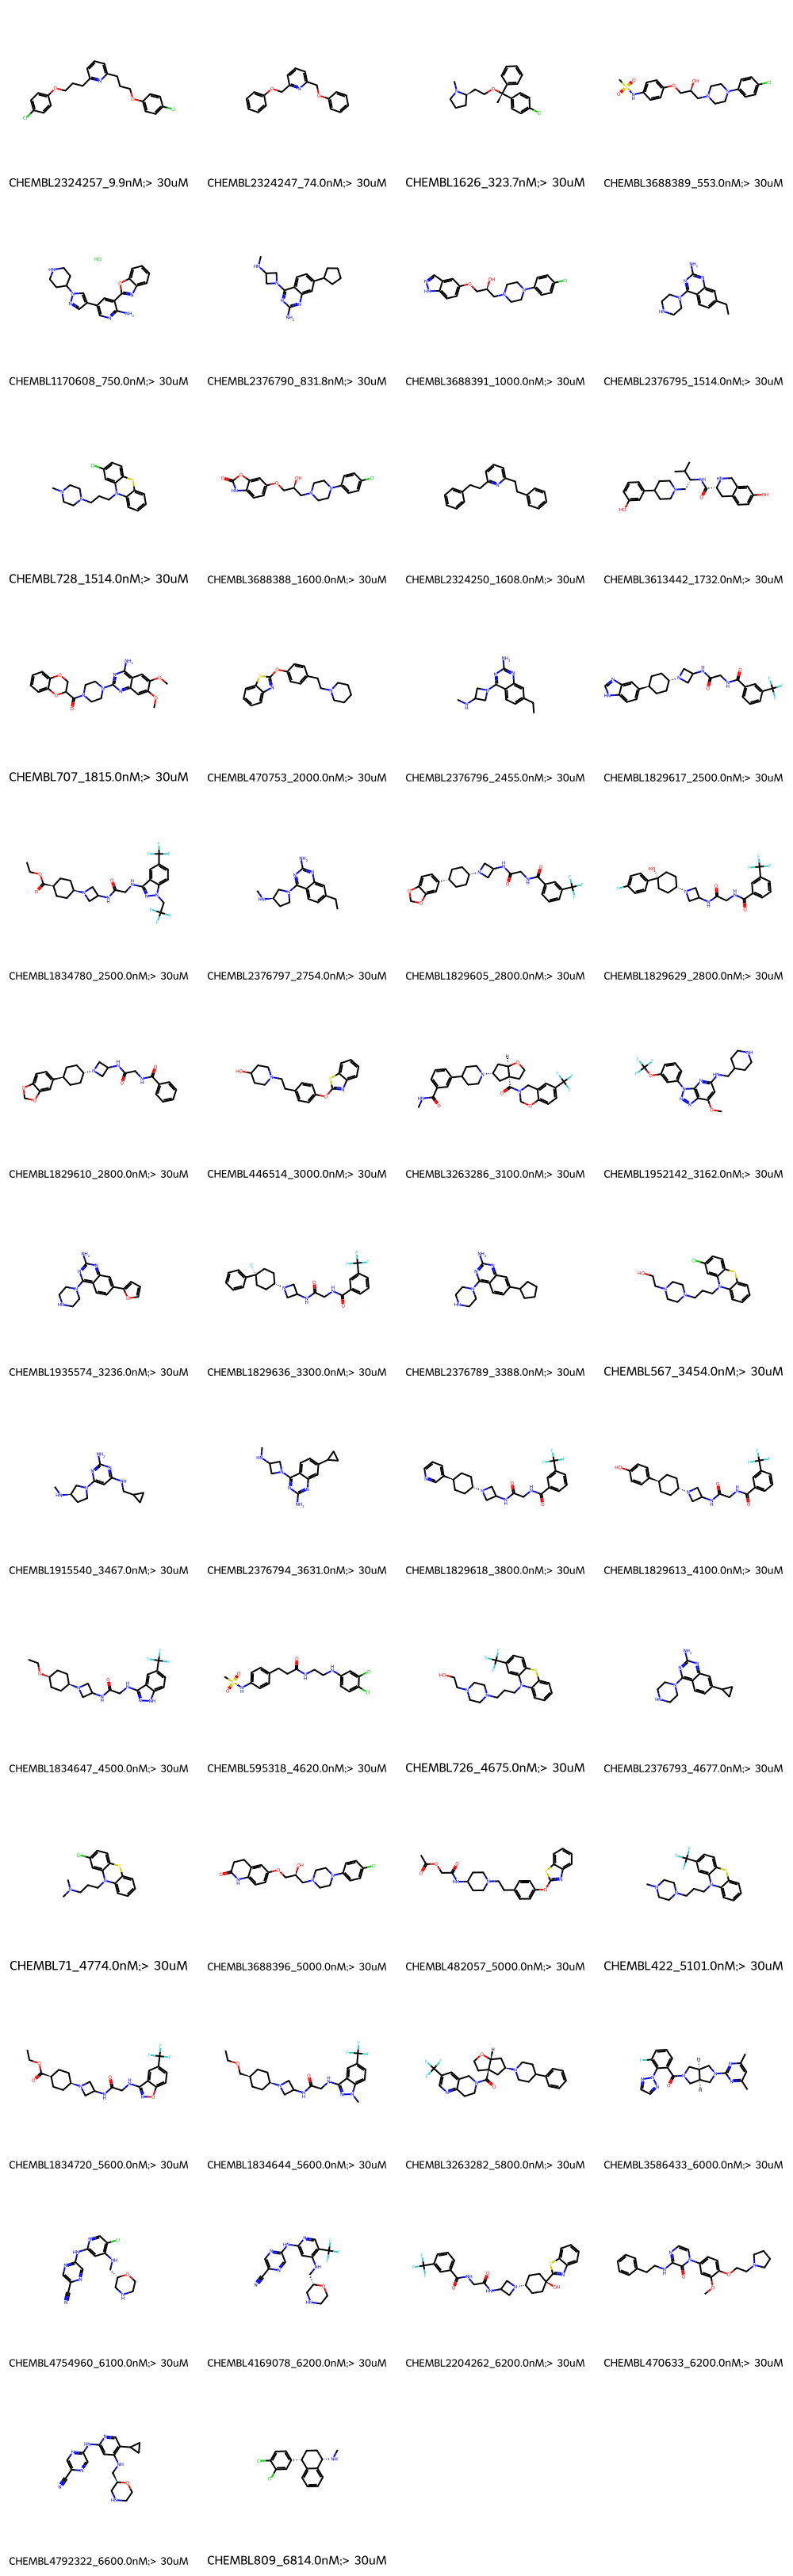

In [307]:
img